# Gender erasure via top-k selection

Erase **gender** from off-the-shelf embeddings using **top-k greedy question selection**:
an LLM expands the concept into a pool of yes/no questions, JEV scores them, and `select_k` greedily
keeps the few that best reconstruct the pool. We then erase with just those and measure held-out
**gender** accuracy before vs. after.

Runs offline from the bundled cache (`USE_CACHE=True`); set it `False` to call the APIs live.

In [1]:
import os, sys, json, hashlib, logging
from pathlib import Path
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')
for _n in ('httpx', 'httpcore', 'openai', 'openai._base_client'):
    logging.getLogger(_n).setLevel(logging.WARNING)       # silence OpenAI/OpenRouter request logs

def _root(s):
    for q in [Path(s).resolve(), *Path(s).resolve().parents]:
        if (q/'pyproject.toml').exists() and (q/'src'/'jevu').exists():
            return q
    return Path(s).resolve()
ROOT = _root(os.getcwd())
if str(ROOT/'src') not in sys.path: sys.path.insert(0, str(ROOT/'src'))
from jevu import ConceptScrubber

_envf = ROOT/'.env'
if _envf.exists():
    for _l in _envf.read_text().splitlines():
        _l = _l.strip()
        if _l and not _l.startswith('#') and '=' in _l:
            _k, _v = _l.split('=', 1); os.environ.setdefault(_k.strip(), _v.strip().strip('\'"'))

USE_CACHE = False        # offline from the bundled cache; set False to call APIs live
CACHE = (ROOT/'examples'/'.jev_debias_cache') if USE_CACHE else None
if CACHE: CACHE.mkdir(parents=True, exist_ok=True)
SEED, N, DENSE_MODEL = 2026, 900, 'text-embedding-3-small'
DATASET, CONFIG, SPLIT = 'LabHC/bias_in_bios', 'default', 'test'
HF_ROWS = 'https://datasets-server.huggingface.co/rows'
def dg(x): return hashlib.sha256(json.dumps(x, sort_keys=True, ensure_ascii=False).encode()).hexdigest()
def sj(p, x): p.write_text(json.dumps(x, ensure_ascii=False))
print('caching:', bool(CACHE))

caching: False


## 1. Data: real bios + off-the-shelf embeddings

In [2]:
def hf_page(off, length=100):
    p = (CACHE/f'bios_{SPLIT}_{off}_{length}.json') if CACHE else None
    if p and p.exists(): return json.loads(p.read_text())
    import httpx
    r = httpx.get(HF_ROWS, params={'dataset': DATASET, 'config': CONFIG, 'split': SPLIT, 'offset': int(off), 'length': int(length)}, timeout=60); r.raise_for_status()
    d = r.json();
    if p: sj(p, d)
    return d

def load_bios(n, seed):
    p = (CACHE/f'bios_sample_{n}_{seed}.json') if CACHE else None
    if p and p.exists(): return json.loads(p.read_text())['rows']
    total = hf_page(0, 1)['num_rows_total']; rng = np.random.default_rng(seed)
    rows = []
    for off in rng.permutation(np.arange(0, total, 100)):
        for it in hf_page(int(off), 100)['rows']:
            r = it['row']; t = str(r['hard_text'] or '').strip()
            if t: rows.append({'text': t[:700], 'prof': int(r['profession']), 'gender': int(r['gender'])})
        if len(rows) >= n: break
    rng.shuffle(rows); rows = rows[:n]
    if p: sj(p, {'rows': rows})
    return rows

def embed_dense(texts):
    p = (CACHE/f'dense_{dg({"m": DENSE_MODEL, "t": texts})}.json') if CACHE else None
    if p and p.exists(): return np.asarray(json.loads(p.read_text()), dtype=float)
    from openai import OpenAI
    cl = OpenAI(timeout=90); v = []
    for s in range(0, len(texts), 200):
        v.extend(x.embedding for x in cl.embeddings.create(model=DENSE_MODEL, input=texts[s:s+200]).data)
    v = np.asarray(v, dtype=float)
    if p: sj(p, v.tolist())
    return v

rows = load_bios(N, SEED)
texts = [r['text'] for r in rows]
prof = np.array([r['prof'] for r in rows]); gender = np.array([r['gender'] for r in rows])
X = normalize(embed_dense(texts))
tr, te = train_test_split(np.arange(N), test_size=0.3, random_state=SEED, stratify=gender)
print(len(texts), 'bios |', len(np.unique(prof)), 'occupations | embeddings', X.shape)

INFO httpx2: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


INFO httpx2: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


INFO httpx2: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


INFO httpx2: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


INFO httpx2: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


900 bios | 28 occupations | embeddings (900, 1536)


## 2. Erase gender with top-k selected questions

Pool of **6** questions; sweep `select_k` to see how few questions you need. The greedy picks are logged (`INFO jevu.scrubber: greedy select …`) and stored in `selected_questions_`.

Selection runs on a **250-row sample** (`select_sample=250`): the pool is scored only on the sample, then just the kept questions are scored on the full train split.

In [3]:
CONCEPT = 'gender'
def acc(A, B): return accuracy_score(gender[te], LogisticRegression(max_iter=2000).fit(A, gender[tr]).predict(B))
print('raw gender acc:', round(acc(X[tr], X[te]), 3))
print('\n--- select_k sweep (greedy from a 6-question pool) ---')
for k in [1, 2, 6]:
    scr = ConceptScrubber(method='leace', expand=True, concept=CONCEPT, n_questions=6,
                          select_k=(None if k == 6 else k), select_sample=250,
                          cache_dir=str(CACHE) if CACHE else None)
    scr.fit(embeddings=X[tr], texts=[texts[i] for i in tr])
    Xd = scr.transform(X)
    kept = scr.selected_questions_ if k != 6 else '(all 6)'
    print(f'  k={k:<2} gender acc {acc(Xd[tr], Xd[te]):.3f}')
    if k != 6:
        for q in scr.selected_questions_: print('        -', q)

raw gender acc: 0.996

--- select_k sweep (greedy from a 6-question pool) ---


INFO httpx2: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO jevu.concepts: expanded concept 'gender' into 6 questions: ['Does the text refer to a woman?', 'Does the text refer to a man?', 'Does the text use gendered pronouns or titles?', 'Does the text imply a female identity through family roles?', 'Does the text imply a male identity through professional roles?', 'Does the text discuss issues specifically related to gender?']


INFO jevu.scrubber: selecting 1/6 questions on a 250-row sample


INFO jevu.concepts: scoring 250 texts x 6 questions = 1500 cells (0 cached, 1500 to fetch)


...

INFO jevu.concepts: expanded concept 'gender' into 6 questions: ['Does the text refer to a woman?', 'Does the text refer to a man?', 'Does the text use gendered pronouns or titles?', 'Does the text mention any specific aspects of femininity?', 'Does the text mention any specific aspects of masculinity?', 'Does the text discuss gender-related topics or issues?']


INFO jevu.concepts: scoring 630 texts x 6 questions = 3780 cells (0 cached, 3780 to fetch)


JEV x6: gender:   0%|          | 0/3780 [00:00<?, ?it/s]

INFO jevu.erasers: LEACE erased concept (d=1536, k=6)


  k=6  gender acc 0.519


## 3. Embeddings before vs. after erasure

x-axis = projection onto the gender direction (a probe's normal), y-axis = 1st PC. Women vs. men separate along the gender axis **before** and collapse onto each other **after** erasing gender.

INFO httpx2: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO jevu.concepts: expanded concept 'gender' into 6 questions: ['Does the text refer to a woman?', 'Does the text refer to a man?', 'Does the text use gendered pronouns or titles?', 'Does the text mention any characteristics typically associated with femininity?', 'Does the text mention any characteristics typically associated with masculinity?', 'Does the text highlight any gender-specific roles or activities?']


INFO jevu.scrubber: selecting 1/6 questions on a 250-row sample


INFO jevu.concepts: scoring 250 texts x 6 questions = 1500 cells (0 cached, 1500 to fetch)


JEV x6: gender:   0%|          | 0/1500 [00:00<?, ?it/s]

INFO jevu.scrubber: greedy select 1/1: 'Does the text refer to a woman?' (reconstruction residual 4.928)


INFO jevu.scrubber: kept 1/6 questions: ['Does the text refer to a woman?']


INFO jevu.concepts: scoring 630 texts x 1 questions = 630 cells (0 cached, 630 to fetch)


JEV x1: gender:   0%|          | 0/630 [00:00<?, ?it/s]

INFO jevu.erasers: LEACE erased concept (d=1536, k=1)


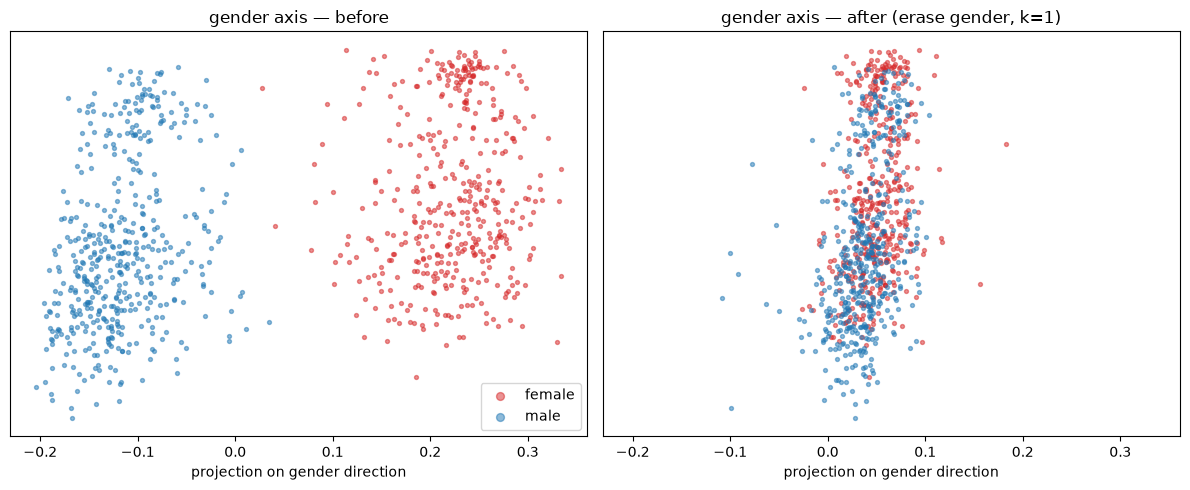

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
scr_v = ConceptScrubber(method='leace', expand=True, concept='gender', n_questions=6,
                        select_k=1, select_sample=250, cache_dir=str(CACHE) if CACHE else None)
scr_v.fit(embeddings=X[tr], texts=[texts[i] for i in tr]); Xd = scr_v.transform(X)
u = LogisticRegression(max_iter=2000).fit(X, gender).coef_[0]; u = u / np.linalg.norm(u)
pc1 = PCA(n_components=1, random_state=SEED).fit_transform(X)[:, 0]
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for axi, (M, ttl) in zip(ax, [(X, 'before'), (Xd, 'after (erase gender, k=1)')]):
    xg = M @ u
    for g, lab, c in [(1, 'female', 'tab:red'), (0, 'male', 'tab:blue')]:
        m = gender == g; axi.scatter(xg[m], pc1[m], s=8, alpha=0.5, c=c, label=lab)
    axi.set_title(f'gender axis — {ttl}'); axi.set_xlabel('projection on gender direction'); axi.set_yticks([])
ax[0].legend(markerscale=2)
plt.tight_layout(); plt.show()

## 4. Reading it

More selected questions → more of the concept removed → lower gender accuracy. A binary concept needs ~1 question; a many-valued identity needs a small covering set. The chosen questions are reusable: deploy just those few to scrub new embeddings cheaply.